In [143]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()


In [144]:
## REQUIRE MEMORY

P = 256
px = 16

Nx = 1024
Ny = 1
Nz = 1024

n = 1

# formulae
M2_s = (20 + 4*n)*Nx*Nz + 8*(Nx/px + Nz*px/P) + 32*P
M3_s = (16 + 2*n)*Nx*Ny*Nz + 4*Nx*Ny + 8*(Nx/px + Nz*px/P) + 40*P

M2_v = (44 + 8*n)*Nx*Nz + 8*(Nx/px + Nz*px/P) + 40*P
M3_v = (56 + 4*n)*Nx*Ny*Nz + 4*Nx*Ny + 8*(Nx/px + Nz*px/P) + 48*P

# IN GB
print('Scalar')
print(M2_s/1000/1000, 'MB')
print(P*M2_s/1000/1000, 'MB')

print('Vector')
print(M2_v/1000/1000/1000, 'GB')
print(P*M2_v/1000/1000/1000, 'GB')


Scalar
25.17504 MB
6444.81024 MB
Vector
0.054537216 GB
13.961527296 GB


In [145]:

SCALINGS = [
    ## My 1D Implementations
    # ~1024^2
    # ~128^3
    {'N': 1048576, 'P': 256, 'D': 1, 'T': 214, 'class': 'FBM', 'MaxRSS': 140684, 'mem': 545.41},
    {'N': 1048576, 'P': 128, 'D': 1, 'T': 247, 'class': 'FBM', 'MaxRSS': 152168, 'mem': 1040.},
    {'N': 1048576, 'P': 64, 'D': 1, 'T': 661, 'class': 'FBM', 'MaxRSS': 152184, 'mem': 1410.},
    {'N': 1048576, 'P': 32, 'D': 1, 'T': 1650., 'class': 'FBM', 'MaxRSS': 152292, 'mem': 285.61},
    {'N': 1048576, 'P': 16, 'D': 1, 'T': 2858., 'class': 'FBM', 'MaxRSS': 152324, 'mem': 284.28},
    {'N': 1048576, 'P': 8, 'D': 1, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    {'N': 1048576, 'P': 4, 'D': 1, 'T': 7245., 'class': 'FBM', 'MaxRSS': 48521532, 'mem': 257.33},
    {'N': 1048576, 'P': 2, 'D': 1, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    {'N': 1048576, 'P': 1, 'D': 1, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},

    # ~2048^2
    {'N': 4194304, 'P': 128, 'D': 1, 'T': 1459, 'class': 'FBM', 'MaxRSS': 272504, 'mem': 2290.},
    {'N': 4194304, 'P': 64, 'D': 1, 'T': 2562, 'class': 'FBM', 'MaxRSS': 272548, 'mem': 1370.},
    {'N': 4194304, 'P': 32, 'D': 1, 'T': 7160, 'class': 'FBM', 'MaxRSS': 260368, 'mem': 502.98},

    # ~1 month wind data
    # ~4096^2
    # ~256^3
    {'N': 16777216, 'P': 128, 'D': 1, 'T': 8917, 'class': 'FBM', 'MaxRSS': 676412, 'mem': 2500.},
    #{'N': 16777216, 'P': 64, 'D': 1, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    #{'N': 16777216, 'P': 32, 'D': 1, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},

    ## 2D scalar fastSF
    {'N': 1024, 'P': 256, 'D': 2, 'T': 37., 'class': 'FBM', 'MaxRSS': 50076, 'mem': 136.92},
    {'N': 1024, 'P': 128, 'D': 2, 'T': 85.021, 'class': 'FBM', 'MaxRSS': 41568, 'mem': None},
    {'N': 1024, 'P': 64, 'D': 2, 'T': 125.215, 'class': 'FBM', 'MaxRSS': 38540, 'mem': None},
    {'N': 1024, 'P': 32, 'D': 2, 'T': 216.534, 'class': 'FBM', 'MaxRSS': 322460, 'mem': None},
    {'N': 1024, 'P': 16, 'D': 2, 'T': 536.624, 'class': 'FBM', 'MaxRSS': 477828, 'mem': None},
    {'N': 1024, 'P': 8, 'D': 2, 'T': 958, 'class': 'FBM', 'MaxRSS': 188624, 'mem': 210.59},
    {'N': 1024, 'P': 4, 'D': 2, 'T': 1041, 'class': 'FBM', 'MaxRSS': 26916, 'mem': 50.61},
    {'N': 1024, 'P': 2, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    {'N': 1024, 'P': 1, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},

    {'N': 2048, 'P': 128, 'D': 2, 'T': 1331.89, 'class': 'FBM', 'MaxRSS': 678624, 'mem': 910.73},
    {'N': 2048, 'P': 64, 'D': 2, 'T': 2183.62, 'class': 'FBM', 'MaxRSS': 122856, 'mem': 757.22},
    {'N': 2048, 'P': 32, 'D': 2, 'T': 4221.57, 'class': 'FBM', 'MaxRSS': None, 'mem': None},

    {'N': 4096, 'P': 128, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    #{'N': 4096, 'P': 64, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    #{'N': 4096, 'P': 32, 'D': 2, 'T': None, 'class': 'FBM', 'MaxRSS': None, 'mem': None},

    ## 3D scalar fastSF
    {'N': 64, 'P': 64, 'D': 3, 'T': 4.37693, 'class': 'FBM', 'MaxRSS': 15124, 'mem': 21.09},
    {'N': 64, 'P': 32, 'D': 3, 'T': 7.41309, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    {'N': 64, 'P': 16, 'D': 3, 'T': 11.5311, 'class': 'FBM', 'MaxRSS': 31012, 'mem': 30.29},

    {'N': 128, 'P': 128, 'D': 3, 'T': 110.947, 'class': 'FBM', 'MaxRSS': 58244, 'mem': 360.08},
    {'N': 128, 'P': 64, 'D': 3, 'T': 172.174, 'class': 'FBM', 'MaxRSS': 62684, 'mem': 403.69},
    {'N': 128, 'P': 32, 'D': 3, 'T': 363.825, 'class': 'FBM', 'MaxRSS': 58244, 'mem': 293.87},

    {'N': 256, 'P': 128, 'D': 3, 'T': 7607.52, 'class': 'FBM', 'MaxRSS': 316976, 'mem': 1350.},
    {'N': 256, 'P': 64, 'D': 3, 'T': 14838.7, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
    {'N': 256, 'P': 32, 'D': 3, 'T': 26060.8, 'class': 'FBM', 'MaxRSS': None, 'mem': None},
]


/home/m/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3398: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/tmp/ipykernel_63438/2643781138.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fancybox=False)


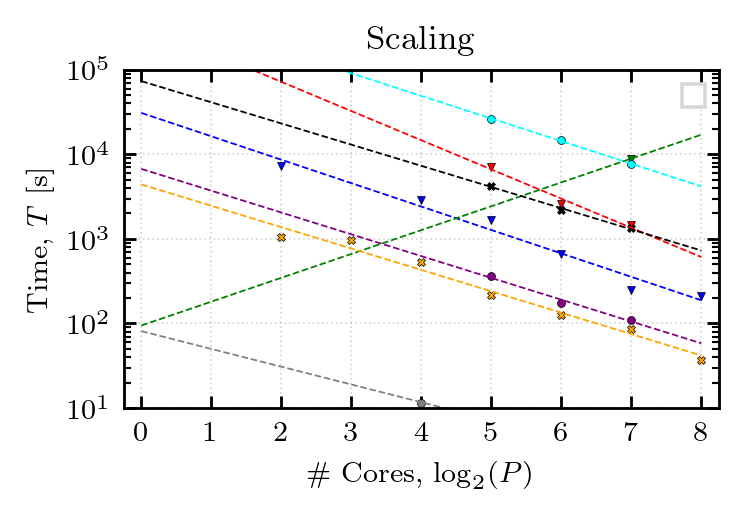

In [146]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas = {}

c = 0
for i, s in enumerate(SCALINGS):
    
    if s['T'] is None:
        continue

    #if s['N'] not in [1048576, 1024, 128]:
    #    continue

    if s['N'] not in cols:
        cols[s['N']] = colors[c]
        c = c + 1

    if s['N'] not in datas:
        datas[s['N']] = {'x': [], 'y': []}
    
    datas[s['N']]['x'].append(s['P'])
    datas[s['N']]['y'].append(s['T'])

    ax.scatter(np.log2(s['P']), s['T'], marker=markers[s['D']], s=5., color=cols[s['N']], zorder=2, linewidth=0.2, edgecolor='black')

P = 10**np.linspace(np.log10(1), np.log10(256), 1000)
for n, data in datas.items():
    f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
    p_n = np.poly1d(f_n)
    ax.plot(np.log2(P), np.exp(p_n(np.log(P))), linewidth=0.5, linestyle='--', color=cols[n])

# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[128], label=r'$128^3$', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[1024], label=r'$1024^2$', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[1048576], label=r'$1048576$', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

ax.set_ylim((1e1, 1e5))
ax.set_xlim((-0.25, 8.25))

ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $T$ [s]')
ax.set_xlabel('\# Cores, $\log_2(P)$')
ax.set_title('Scaling')

ax.legend(fancybox=False)


In [147]:

STRONG_SCALING = [
    {'N': 262144, 'P': 1, 'D': 1, 'T': 232.6035556793213, 'class': 'FBM', 'mem': 108.32},
    {'N': 262144, 'P': 2, 'D': 1, 'T': 215.51528573036194, 'class': 'FBM', 'mem': 108.32},
    {'N': 262144, 'P': 4, 'D': 1, 'T': 128.2691946029663, 'class': 'FBM', 'mem': 73.00},
    {'N': 262144, 'P': 8, 'D': 1, 'T': 96.5174400806427, 'class': 'FBM', 'mem': 151.09},
    {'N': 262144, 'P': 16, 'D': 1, 'T': 44.27000331878662, 'class': 'FBM', 'mem': 265.09},
    {'N': 262144, 'P': 32, 'D': 1, 'T': 29.9702467918396, 'class': 'FBM', 'mem': 339.55},
    {'N': 262144, 'P': 64, 'D': 1, 'T': 24.101096153259277, 'class': 'FBM', 'mem': 425.34},
    {'N': 262144, 'P': 128, 'D': 1, 'T': 10.593275547027588, 'class': 'FBM', 'mem': 1120},

    {'N': 512, 'P': 1, 'D': 2, 'T': 124.596, 'class': 'FBM', 'mem': 16.67, 'PX': 1},
    {'N': 512, 'P': 2, 'D': 2, 'T': 125.61, 'class': 'FBM', 'mem': 16.75, 'PX': 1},
    {'N': 512, 'P': 4, 'D': 2, 'T': 58.3806, 'class': 'FBM', 'mem': 21.08, 'PX': 1},
    {'N': 512, 'P': 8, 'D': 2, 'T': 29.5061, 'class': 'FBM', 'mem': 5.66, 'PX': 1},
    {'N': 512, 'P': 16, 'D': 2, 'T': 31.5822, 'class': 'FBM', 'mem': 43.88, 'PX': 1},
    {'N': 512, 'P': 32, 'D': 2, 'T': 16.7708, 'class': 'FBM', 'mem': 10.00, 'PX': 1},
    {'N': 512, 'P': 64, 'D': 2, 'T': 6.73415, 'class': 'FBM', 'mem': 165.66, 'PX': 1},
    {'N': 512, 'P': 128, 'D': 2, 'T': 4.45808, 'class': 'FBM', 'mem': 75.55, 'PX': 1},

    {'N': 64, 'P': 1, 'D': 3, 'T': 48.9078, 'class': 'FBM', 'mem': 16.22, 'PX': 1},
    {'N': 64, 'P': 2, 'D': 3, 'T': 49.5735, 'class': 'FBM', 'mem': 16.22, 'PX': 1},
    {'N': 64, 'P': 4, 'D': 3, 'T': 24.8452, 'class': 'FBM', 'mem': 5.47, 'PX': 1},
    {'N': 64, 'P': 8, 'D': 3, 'T': 24.5089, 'class': 'FBM', 'mem': 5.47, 'PX': 1},
    {'N': 64, 'P': 16, 'D': 3, 'T': 6.31579, 'class': 'FBM', 'mem': 0.284, 'PX': 1},
    {'N': 64, 'P': 32, 'D': 3, 'T': 6.5989, 'class': 'FBM', 'mem': 13.66, 'PX': 1},
    {'N': 64, 'P': 64, 'D': 3, 'T': 3.51749, 'class': 'FBM', 'mem': 63.06, 'PX': 1},
    {'N': 64, 'P': 128, 'D': 3, 'T': 2.94823, 'class': 'FBM', 'mem': 22.20, 'PX': 2},
]


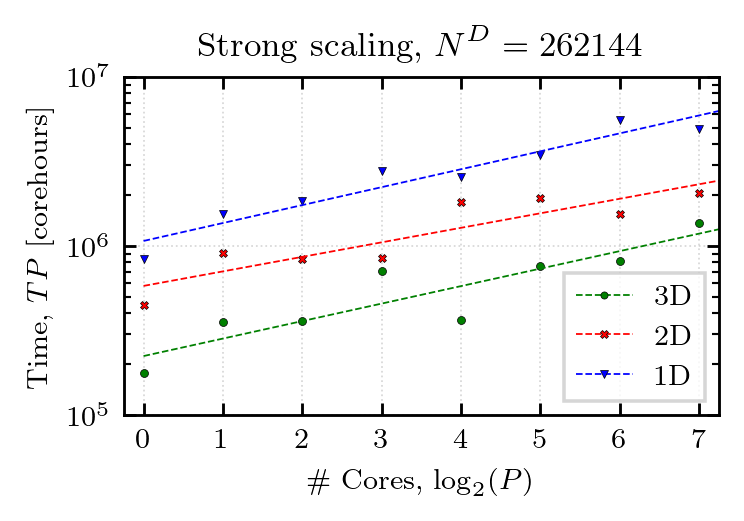

In [148]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas = {}

c = 0
for i, s in enumerate(STRONG_SCALING):
    
    if s['T'] is None:
        continue

    if s['N'] not in cols:
        cols[s['N']] = colors[c]
        c = c + 1

    if s['N'] not in datas:
        datas[s['N']] = {'x': [], 'y': []}
    
    datas[s['N']]['x'].append(s['P'])
    datas[s['N']]['y'].append(s['T']*60.*60.*s['P'])

    ax.scatter(np.log2(s['P']), s['T']*60.*60.*s['P'], marker=markers[s['D']], s=5., color=cols[s['N']], zorder=2, linewidth=0.2, edgecolor='black')

P = 10**np.linspace(np.log10(1), np.log10(256), 1000)
for n, data in datas.items():
    f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
    p_n = np.poly1d(f_n)
    ax.plot(np.log2(P), np.exp(p_n(np.log(P))), linewidth=0.5, linestyle='--', color=cols[n])

ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[64], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[512], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[262144], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

ax.set_ylim((1e5, 1e7))
ax.set_xlim((-0.25, 7.25))
#ax.set_xlim((0.75, 7.25))

ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7])

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $TP$ [corehours]')
ax.set_xlabel('\# Cores, $\log_2(P)$')
ax.set_title('Strong scaling, $N^D = 262144$')

ax.legend(fancybox=False)


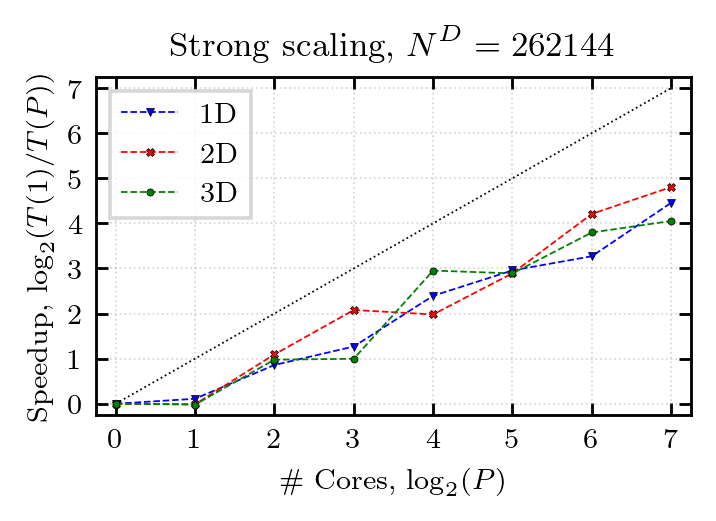

In [149]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas = {}

c = 0
for i, s in enumerate(STRONG_SCALING):
    
    if s['T'] is None:
        continue

    if s['N'] not in cols:
        cols[s['N']] = colors[c]
        c = c + 1

    if s['N'] not in datas:
        datas[s['N']] = {'x': [], 'y': []}
    
    datas[s['N']]['x'].append(s['P'])
    datas[s['N']]['y'].append(s['T'])
    #BT = datas[s['N']]['y'][0]

    #ax.scatter(np.log2(s['P']), np.log2(BT/s['T']), marker=markers[s['D']], s=5., color=cols[s['N']], zorder=2, linewidth=0.2, edgecolor='black')

# P = 10**np.linspace(np.log10(1), np.log10(256), 1000)
# for n, data in datas.items():
#     f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
#     p_n = np.poly1d(f_n)
#     ax.plot(np.log2(P), np.log2(np.exp(p_n(np.log(1))) / np.exp(p_n(np.log(P)))), linewidth=0.5, linestyle='--', color=cols[n])

ax.plot(np.linspace(0, 7), np.linspace(0, 7), linestyle=':', linewidth=0.5, color='black')

ax.plot(np.log2(datas[262144]['x']), np.log2(datas[262144]['y'][0]/np.array(datas[262144]['y'])), linewidth=0.5, linestyle='--', color=cols[262144], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot(np.log2(datas[512]['x']), np.log2(datas[512]['y'][0]/np.array(datas[512]['y'])), linewidth=0.5, linestyle='--', color=cols[512], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot(np.log2(datas[64]['x']), np.log2(datas[64]['y'][0]/np.array(datas[64]['y'])), linewidth=0.5, linestyle='--', color=cols[64], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[64], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[512], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[262144], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

ax.set_xlim((-0.25, 7.25))
ax.set_ylim((-0.25, 7.25))

#ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

# locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
# ax.yaxis.set_major_locator(locmaj)
# locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
# ax.yaxis.set_minor_locator(locmin)

ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7])
ax.set_yticks([0, 1, 2, 3, 4, 5, 6, 7])

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Speedup, $\log_2(T(1)/T(P))$')
ax.set_xlabel('\# Cores, $\log_2(P)$')
ax.set_title('Strong scaling, $N^D = 262144$')

ax.legend(fancybox=False)


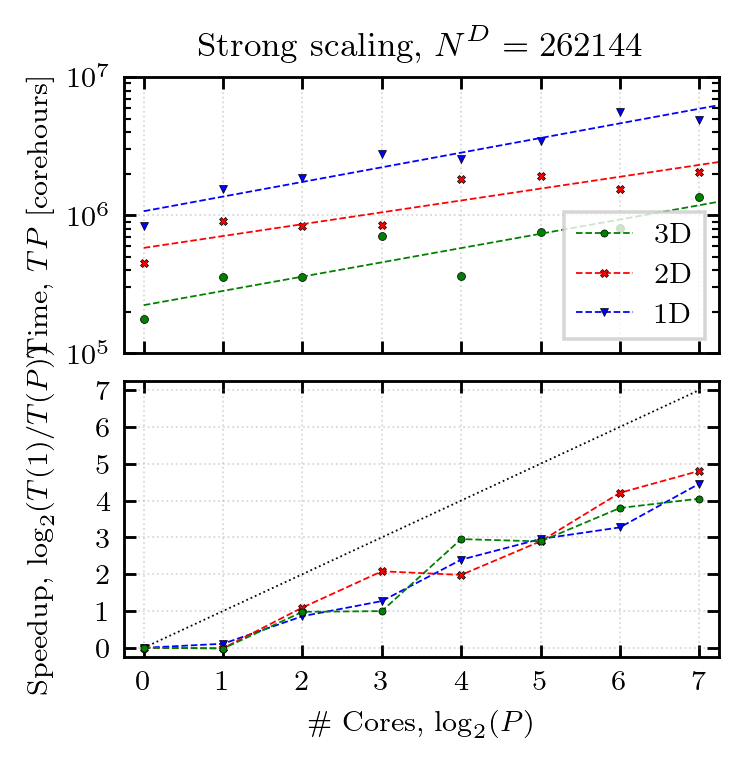

In [150]:

fig, ax = plt.subplots(2, 1, figsize=(3., 3.), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas1 = {}
datas2 = {}

c = 0
for i, s in enumerate(STRONG_SCALING):
    
    if s['T'] is None:
        continue

    if s['N'] not in cols:
        cols[s['N']] = colors[c]
        c = c + 1

    if s['N'] not in datas1:
        datas1[s['N']] = {'x': [], 'y': []}
    if s['N'] not in datas2:
        datas2[s['N']] = {'x': [], 'y': []}
    
    datas1[s['N']]['x'].append(s['P'])
    datas1[s['N']]['y'].append(s['T']*60.*60.*s['P'])
    datas2[s['N']]['x'].append(s['P'])
    datas2[s['N']]['y'].append(s['T'])

    ax[0].scatter(np.log2(s['P']), s['T']*60.*60.*s['P'], marker=markers[s['D']], s=5., color=cols[s['N']], zorder=2, linewidth=0.2, edgecolor='black')

P = 10**np.linspace(np.log10(1), np.log10(256), 1000)
for n, data in datas1.items():
    f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
    p_n = np.poly1d(f_n)
    ax[0].plot(np.log2(P), np.exp(p_n(np.log(P))), linewidth=0.5, linestyle='--', color=cols[n])

ax[0].plot([], [], linewidth=0.5, linestyle='--', color=cols[64], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[0].plot([], [], linewidth=0.5, linestyle='--', color=cols[512], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[0].plot([], [], linewidth=0.5, linestyle='--', color=cols[262144], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

ax[1].plot(np.linspace(0, 7), np.linspace(0, 7), linestyle=':', linewidth=0.5, color='black')

ax[1].plot(np.log2(datas2[262144]['x']), np.log2(datas2[262144]['y'][0]/np.array(datas2[262144]['y'])), linewidth=0.5, linestyle='--', color=cols[262144], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[1].plot(np.log2(datas2[512]['x']), np.log2(datas2[512]['y'][0]/np.array(datas2[512]['y'])), linewidth=0.5, linestyle='--', color=cols[512], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[1].plot(np.log2(datas2[64]['x']), np.log2(datas2[64]['y'][0]/np.array(datas2[64]['y'])), linewidth=0.5, linestyle='--', color=cols[64], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

ax[0].set_ylim((1e5, 1e7))
ax[0].set_xlim((-0.25, 7.25))
ax[0].set_yscale('log')
ax[0].set_xticks([0, 1, 2, 3, 4, 5, 6, 7], [])

ax[1].set_ylim((-0.25, 7.25))
ax[1].set_xlim((-0.25, 7.25))
ax[1].set_yticks([0, 1, 2, 3, 4, 5, 6, 7])

ax[1].set_xticks([0, 1, 2, 3, 4, 5, 6, 7], [0, 1, 2, 3, 4, 5, 6, 7])

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax[0].yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax[0].yaxis.set_minor_locator(locmin)

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')

    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[1].set_ylabel('Speedup, $\log_2(T(1)/T(P))$')
ax[0].set_ylabel('Time, $TP$ [corehours]')
ax[1].set_xlabel('\# Cores, $\log_2(P)$')
ax[0].set_title('Strong scaling, $N^D = 262144$')

ax[0].legend(fancybox=False)

fig.subplots_adjust(hspace=0.1)
fig.align_ylabels()

fig.savefig('SF_strong_scaling.pdf', bbox_inches='tight', pad_inches=0)


In [151]:

NpP = 65536
Ns = {2**n: NpP*2**n for n in range(0,8)}
print(Ns)

NpP = 65536
N2s = {2**n: int(np.sqrt(NpP*(2**n))) for n in range(0,8)}
print(N2s)

NpP = 65536
N3s = {2**n: int(np.cbrt(NpP*(2**n))) for n in range(0,8)}
print(N3s)


{1: 65536, 2: 131072, 4: 262144, 8: 524288, 16: 1048576, 32: 2097152, 64: 4194304, 128: 8388608}
{1: 256, 2: 362, 4: 512, 8: 724, 16: 1024, 32: 1448, 64: 2048, 128: 2896}
{1: 40, 2: 50, 4: 64, 8: 80, 16: 101, 32: 128, 64: 161, 128: 203}


In [152]:

WEAK_SCALING = [
    {'N': 65536, 'N/P': 65536, 'P': 1, 'D': 1, 'T': 16.53225541114807, 'class': 'FBM', 'mem': 100.32},
    {'N': 131072, 'N/P': 65536, 'P': 2, 'D': 1, 'T': 54.691039085388184, 'class': 'FBM', 'mem': 98.63},
    {'N': 262144, 'N/P': 65536, 'P': 4, 'D': 1, 'T': 128.2691946029663, 'class': 'FBM', 'mem': 73.00},
    {'N': 524288, 'N/P': 65536, 'P': 8, 'D': 1, 'T': 267.25963854789734, 'class': 'FBM', 'mem': 127.14},
    {'N': 1048576, 'N/P': 65536, 'P': 16, 'D': 1, 'T': 1209.9544208049774, 'class': 'FBM', 'mem': 284.30},
    {'N': 2097152, 'N/P': 65536, 'P': 32, 'D': 1, 'T': 3591.045530796051, 'class': 'FBM', 'mem': 558.46},
    {'N': 4194304, 'N/P': 65536, 'P': 64, 'D': 1, 'T': 9982.134246349335, 'class': 'FBM', 'mem': 2520},
    {'N': 8388608, 'N/P': 65536, 'P': 128, 'D': 1, 'T': None, 'class': 'FBM', 'mem': None},

    {'N': 256, 'N/P': 65536, 'P': 1, 'D': 2, 'T': 7.29966, 'class': 'FBM', 'mem': None, 'PX': 1},
    {'N': 362, 'N/P': 65536, 'P': 2, 'D': 2, 'T': 28.825, 'class': 'FBM', 'mem': 5.37, 'PX': 1},
    {'N': 512, 'N/P': 65536, 'P': 4, 'D': 2, 'T': 58.3806, 'class': 'FBM', 'mem': 21.08, 'PX': 1},
    {'N': 724, 'N/P': 65536, 'P': 8, 'D': 2, 'T': 117.026, 'class': 'FBM', 'mem': 72.25, 'PX': 2},
    {'N': 1024, 'N/P': 65536, 'P': 16, 'D': 2, 'T': 264.563, 'class': 'FBM', 'mem': 225.08, 'PX': 1},
    {'N': 1448, 'N/P': 65536, 'P': 32, 'D': 2, 'T': 959.96, 'class': 'FBM', 'mem': 255.25, 'PX': 4},
    {'N': 2048, 'N/P': 65536, 'P': 64, 'D': 2, 'T': 2113.85, 'class': 'FBM', 'mem': 1700, 'PX': 1},
    {'N': 2896, 'N/P': 65536, 'P': 128, 'D': 2, 'T': None, 'class': 'FBM', 'mem': None, 'PX': 8},

    {'N': 40, 'N/P': 65536, 'P': 1, 'D': 3, 'T': 3.04004, 'class': 'FBM', 'mem': None, 'PX': 1},
    {'N': 50, 'N/P': 65536, 'P': 2, 'D': 3, 'T': 10.9849, 'class': 'FBM', 'mem': None, 'PX': 1},
    {'N': 64, 'N/P': 65536, 'P': 4, 'D': 3, 'T': 26.7277, 'class': 'FBM', 'mem': 5.37, 'PX': 1},
    {'N': 80, 'N/P': 65536, 'P': 8, 'D': 3, 'T': 54.9402, 'class': 'FBM', 'mem': 59.34, 'PX': 1},
    {'N': 102, 'N/P': 65536, 'P': 16, 'D': 3, 'T': None, 'class': 'FBM', 'mem': None, 'PX': 2},
    {'N': 128, 'N/P': 65536, 'P': 32, 'D': 3, 'T': 336.471, 'class': 'FBM', 'mem': 430.01, 'PX': 1},
    {'N': 162, 'N/P': 65536, 'P': 64, 'D': 3, 'T': 2113.85, 'class': 'FBM', 'mem': 341.70, 'PX': 1},
    {'N': 204, 'N/P': 65536, 'P': 128, 'D': 3, 'T': None, 'class': 'FBM', 'mem': None, 'PX': 1},
]


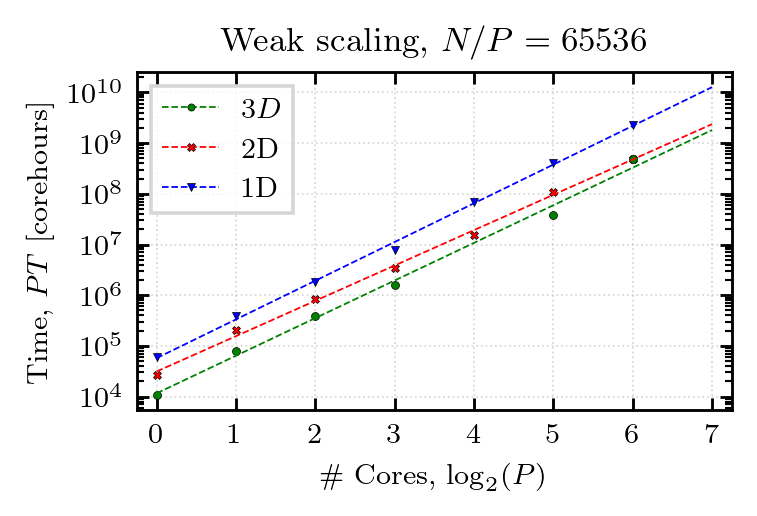

In [153]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas = {}

c = 0
for i, s in enumerate(WEAK_SCALING):
    
    if s['T'] is None:
        continue

    PS = int(s['D'])

    if PS not in cols:
        cols[PS] = colors[c]
        c = c + 1

    if PS not in datas:
        datas[PS] = {'x': [], 'y': []}

    datas[PS]['x'].append(s['P'])
    datas[PS]['y'].append(s['T']*60.*60.*s['P'])

    ax.scatter(np.log2(s['P']), s['T']*60.*60.*s['P'], marker=markers[s['D']], s=5., color=cols[PS], zorder=2, linewidth=0.2, edgecolor='black')

P = 10**np.linspace(np.log10(1), np.log10(128), 1000)
for n, data in datas.items():
    f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
    p_n = np.poly1d(f_n)
    ax.plot(np.log2(P), np.exp(p_n(np.log(P))), linewidth=0.5, linestyle='--', color=cols[n])


ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[3], label=r'$3D$', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[2], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[1], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

#ax.set_ylim((1e1, 1e5))
ax.set_xlim((-0.25, 7.25))

ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7])

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $PT$ [corehours]')
ax.set_xlabel('\# Cores, $\log_2(P)$')
ax.set_title('Weak scaling, $N/P=65536$')

ax.legend(fancybox=False)


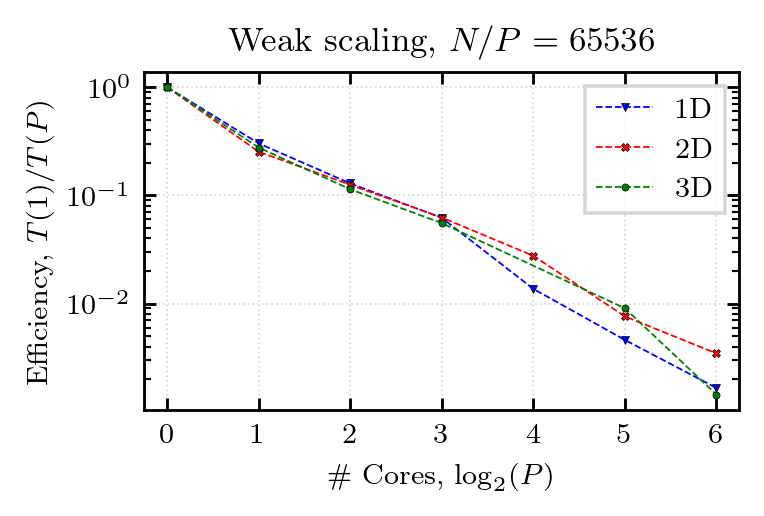

In [154]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas = {}

c = 0
for i, s in enumerate(WEAK_SCALING):
    
    if s['T'] is None:
        continue

    PS = int(s['D'])

    if PS not in cols:
        cols[PS] = colors[c]
        c = c + 1

    if PS not in datas:
        datas[PS] = {'x': [], 'y': []}

    datas[PS]['x'].append(s['P'])
    datas[PS]['y'].append(s['T'])

    BT = datas[PS]['y'][0]

    #ax.scatter(np.log2(s['P']), BT/s['T'], marker=markers[s['D']], s=5., color=cols[PS], zorder=2, linewidth=0.2, edgecolor='black')

# P = 10**np.linspace(np.log10(1), np.log10(128), 1000)
# for n, data in datas.items():
#     f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
#     p_n = np.poly1d(f_n)
#     ax.plot(np.log2(P), np.exp(p_n(np.log(1)))/np.exp(p_n(np.log(P))), linewidth=0.5, linestyle='--', color=cols[n])

ax.plot(np.log2(datas[1]['x']), datas[1]['y'][0]/np.array(datas[1]['y']), linewidth=0.5, linestyle='--', color=cols[1], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot(np.log2(datas[2]['x']), datas[2]['y'][0]/np.array(datas[2]['y']), linewidth=0.5, linestyle='--', color=cols[2], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax.plot(np.log2(datas[3]['x']), datas[3]['y'][0]/np.array(datas[3]['y']), linewidth=0.5, linestyle='--', color=cols[3], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[1], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[2], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
# ax.plot([], [], linewidth=0.5, linestyle='--', color=cols[3], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

#ax.set_ylim((-0.1, 1.1))
ax.set_xlim((-0.25, 6.25))

ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.set_xticks([0, 1, 2, 3, 4, 5, 6])

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Efficiency, $T(1)/T(P)$')
ax.set_xlabel('\# Cores, $\log_2(P)$')
ax.set_title('Weak scaling, $N/P=65536$')

ax.legend(fancybox=False)


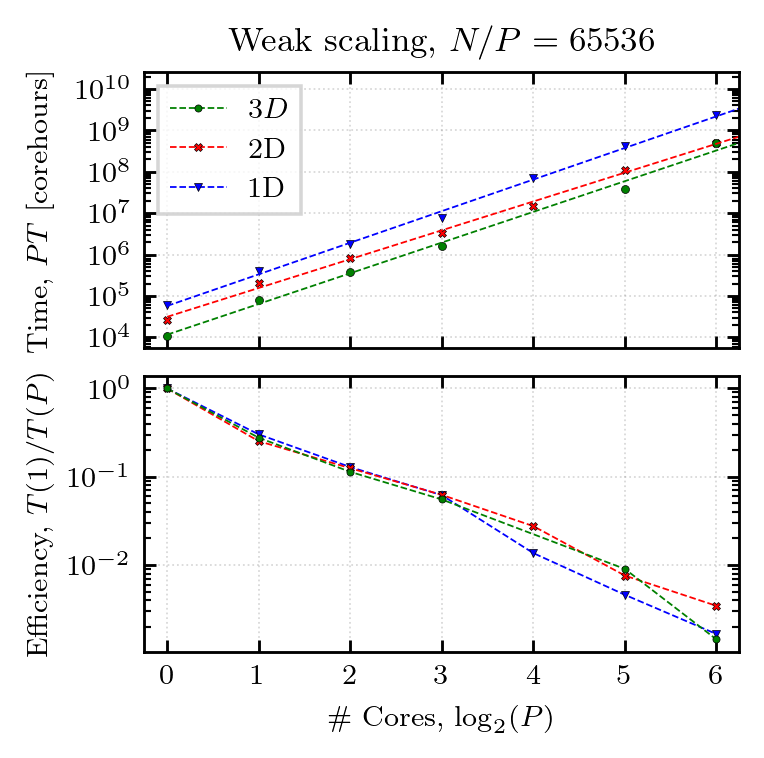

In [155]:

fig, ax = plt.subplots(2, 1, figsize=(3., 3.), dpi=256, sharex=True)

markers = {1: 'v', 2: 'X', 3: 'o'}
colors = ['blue', 'red', 'green', 'orange', 'black', 'gray', 'purple', 'cyan', 'pink']
cols = {}

datas1 = {}
datas2 = {}

c = 0
for i, s in enumerate(WEAK_SCALING):
    
    if s['T'] is None:
        continue

    PS = int(s['D'])

    if PS not in cols:
        cols[PS] = colors[c]
        c = c + 1

    if PS not in datas1:
        datas1[PS] = {'x': [], 'y': []}
    if PS not in datas2:
        datas2[PS] = {'x': [], 'y': []}

    datas1[PS]['x'].append(s['P'])
    datas1[PS]['y'].append(s['T']*60.*60.*s['P'])
    datas2[PS]['x'].append(s['P'])
    datas2[PS]['y'].append(s['T'])

    ax[0].scatter(np.log2(s['P']), s['T']*60.*60.*s['P'], marker=markers[s['D']], s=5., color=cols[PS], zorder=2, linewidth=0.2, edgecolor='black')

P = 10**np.linspace(np.log10(1), np.log10(128), 1000)
for n, data in datas1.items():
    f_n = np.polyfit(np.log(np.array(data['x'])), np.log(np.array(data['y'])), deg=1)
    p_n = np.poly1d(f_n)
    ax[0].plot(np.log2(P), np.exp(p_n(np.log(P))), linewidth=0.5, linestyle='--', color=cols[n])

ax[0].plot([], [], linewidth=0.5, linestyle='--', color=cols[3], label=r'$3D$', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[0].plot([], [], linewidth=0.5, linestyle='--', color=cols[2], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[0].plot([], [], linewidth=0.5, linestyle='--', color=cols[1], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

ax[1].plot(np.log2(datas2[1]['x']), datas2[1]['y'][0]/np.array(datas2[1]['y']), linewidth=0.5, linestyle='--', color=cols[1], label=r'1D', marker=markers[1], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[1].plot(np.log2(datas2[2]['x']), datas2[2]['y'][0]/np.array(datas2[2]['y']), linewidth=0.5, linestyle='--', color=cols[2], label=r'2D', marker=markers[2], markeredgecolor='black', markersize=2., markeredgewidth=0.2)
ax[1].plot(np.log2(datas2[3]['x']), datas2[3]['y'][0]/np.array(datas2[3]['y']), linewidth=0.5, linestyle='--', color=cols[3], label=r'3D', marker=markers[3], markeredgecolor='black', markersize=2., markeredgewidth=0.2)

#ax.set_ylim((1e1, 1e5))
for axx in ax:
    axx.set_xlim((-0.25, 6.25))

    axx.set_yscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    axx.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    axx.yaxis.set_minor_locator(locmin)

    axx.set_xticks([0, 1, 2, 3, 4, 5, 6])

    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel('Time, $PT$ [corehours]')
ax[1].set_ylabel('Efficiency, $T(1)/T(P)$')
ax[1].set_xlabel('\# Cores, $\log_2(P)$')
ax[0].set_title('Weak scaling, $N/P=65536$')

ax[0].legend(fancybox=False)

fig.align_ylabels()
fig.subplots_adjust(hspace=0.1)

fig.savefig('SF_weak_scaling.pdf', bbox_inches='tight', pad_inches=0)


In [156]:

# fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

# #markers = {'FBM': 'X', 'SIM': 'o'}
# markers = {1: 'v', 2: 'X', 3: 'o'}
# colors = {4: 'orange', 8: 'black', 16: 'gray', 32: 'green', 64: 'red', 128: 'blue'}

# x_32, y_32 = [], []
# x_64, y_64 = [], []
# x_128, y_128 = [], []

# for s in SCALINGS:
#     if s['T'] is None:
#         continue

#     if s['P'] == 32:
#         x_32.append(s['N']**s['D'])
#         y_32.append(s['T'])
#     elif s['P'] == 64:
#         x_64.append(s['N']**s['D'])
#         y_64.append(s['T'])
#     elif s['P'] == 128:
#         x_128.append(s['N']**s['D'])
#         y_128.append(s['T'])

#     ax.scatter(s['N']**s['D'], s['T'], marker=markers[s['D']], s=5., color=colors[s['P']], zorder=2, linewidth=0.2, edgecolor='black')


# # f_32 = np.polyfit(np.log(x_32), np.log(y_32), deg=1)
# # p_32 = np.poly1d(f_32)
# # f_64 = np.polyfit(np.log(x_64), np.log(y_64), deg=1)
# # p_64 = np.poly1d(f_64)
# # f_128 = np.polyfit(np.log(x_128), np.log(y_128), deg=1)
# # p_128 = np.poly1d(f_128)

# # print(f_32, f_64, f_128)

# # C = ['green', 'red', 'blue']
# # N = 10**np.linspace(np.log10(1e5), np.log10(1e9), 1000)
# # for i, f in enumerate([p_32, p_64, p_128]):
# #     ax.plot(N, np.exp(f(np.log(N))), linewidth=0.5, linestyle='--', color=C[i])

# # # t_est_64 = np.exp(p_64(np.log(1024**3)))
# # # t_est_128 = np.exp(p_128(np.log(1024**3)))
# # # print('Estimated time for 1024^3, 64 cores:', t_est_64/60./60./24., '[days]')
# # # print('Estimated time for 1024^3, 128 cores:', t_est_128/60./60./24., '[days]')
# # # # ax.scatter(1024**3, t_est_64, marker=markers[3], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
# # # # ax.scatter(1024**3, t_est_128, marker=markers[3], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')

# # t_est_64 = np.exp(p_64(np.log(4096**2)))
# # t_est_128 = np.exp(p_128(np.log(4096**2)))
# # print('Estimated time for 8192^2, 64 cores:', t_est_64/60./60./24., '[days]')
# # print('Estimated time for 8192^2, 128 cores:', t_est_128/60./60./24., '[days]')
# # ax.scatter(4096**2, t_est_64, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
# # ax.scatter(4096**2, t_est_128, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')

# # t_est_64 = np.exp(p_64(np.log(16384**2)))
# # t_est_128 = np.exp(p_128(np.log(16384**2)))
# # print('Estimated time for 16000^2, 64 cores:', t_est_64/60./60./24., '[days]')
# # print('Estimated time for 16000^2, 128 cores:', t_est_128/60./60./24., '[days]')
# # # ax.scatter(16384**2, t_est_64, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
# # # ax.scatter(16384**2, t_est_128, marker=markers[2], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')


# # props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
# # ax.text(1.5e7, 0.6, '32 Cores', color='green', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)
# # ax.text(1.5e8, 0.725, '64 Cores', color='red', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)
# # ax.text(1.5e8, 0.58, '128 Cores', color='blue', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)

# ax.set_yscale('log')
# ax.set_xscale('log')
# ax.yaxis.set_ticks_position('both')
# ax.xaxis.set_ticks_position('both')
# ax.tick_params(axis='y', direction='in')
# ax.tick_params(axis='y', direction='in', which='minor')
# ax.tick_params(axis='x', direction='in')
# ax.tick_params(axis='x', direction='in', which='minor')

# locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
# ax.yaxis.set_major_locator(locmaj)
# locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
# ax.yaxis.set_minor_locator(locmin)

# locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
# ax.xaxis.set_major_locator(locmaj)
# locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
# ax.xaxis.set_minor_locator(locmin)

# ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

# ax.set_ylabel('Time, $T$ [s]')
# ax.set_xlabel('Grid size, $n=N^D$')

# # txt = r'''
# # Scaling for fastSF:
# # $\ln(T)={%s}\ln(n){%s}$
# # $\ln(T)={%s}\ln(n){%s}$
# # $\ln(T)={%s}\ln(n){%s}$
# # ''' % (f_32[0].round(decimals=2), f_32[1].round(decimals=2), f_64[0].round(decimals=2), f_64[1].round(decimals=2), f_128[0].round(decimals=2), f_128[1].round(decimals=2))
# # fig.text(0.1, -0.2, txt, wrap=True, horizontalalignment='left', verticalalignment='top')

# fig.savefig('fastSF_scaling.pdf', bbox_inches='tight', pad_inches=0)
